1. Setup & Environment
2. Dataset Loading & Class Distribution
3. Text Metrics Analysis (Word Counts & Token Statistics)
4. Top Token Frequency & Semantic Separation
5. Dimensionality Reduction (Sparse PCA, Scree Plot & Biplot)
6. Baseline Model Sanity Checks & Preliminary Receiver Operating Characteristic (ROC) Curves

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to system path for modular imports
sys.path.append(os.path.abspath('..'))

import config
from src.preprocessing import DataPreprocessor
from src.baseline_models import get_baseline_models

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

Dataset Shape: (7731, 2)
                                          clean_text  is_depression
0  we understand that most people who reply immed...              1
1  welcome to r depression s check in post a plac...              1
2  anyone else instead of sleeping more when depr...              1
3  i ve kind of stuffed around a lot in my life d...              1
4  sleep is my greatest and most comforting escap...              1


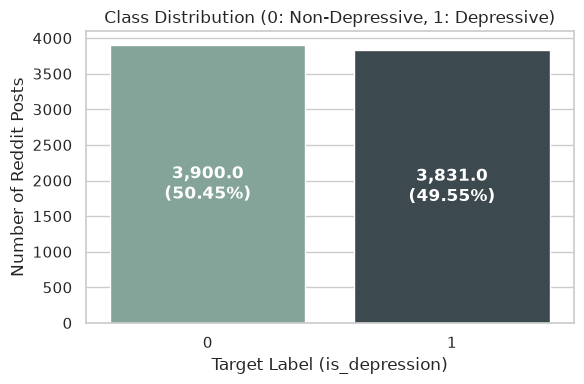

In [3]:
# Load dataset
df = pd.read_csv(os.path.join("..", config.DATA_RAW_PATH))
print(f"Dataset Shape: {df.shape}")
print(df.head())

# Plot Class Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x='is_depression', 
    hue='is_depression', 
    data=df, 
    palette=['#7FA99B', '#394A51'], 
    legend=False
)
plt.title("Class Distribution (0: Non-Depressive, 1: Depressive)")
plt.xlabel("Target Label (is_depression)")
plt.ylabel("Number of Reddit Posts")

# Annotate counts
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(f'{p.get_height():,}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Word Count Summary by Class:
                count        mean         std  min   25%   50%    75%     max
is_depression                                                                
0              3900.0   14.294615    7.267336  1.0   8.0  13.0   20.0    42.0
1              3831.0  136.087184  185.829237  1.0  32.0  78.0  174.0  4239.0


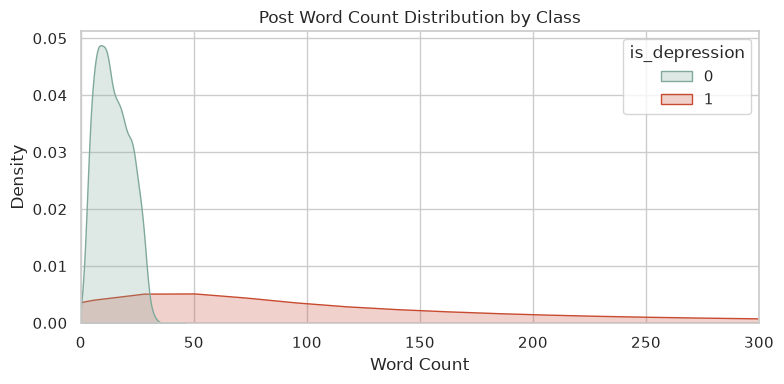

In [4]:
# Compute word count per post
df['word_count'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))

# Statistical summary of word count by class
print("Word Count Summary by Class:")
print(df.groupby('is_depression')['word_count'].describe())

# Density distribution plot
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='word_count', hue='is_depression', common_norm=False, fill=True, palette=['#7FA99B', '#C84B31'])
plt.xlim(0, 300)
plt.title("Post Word Count Distribution by Class")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

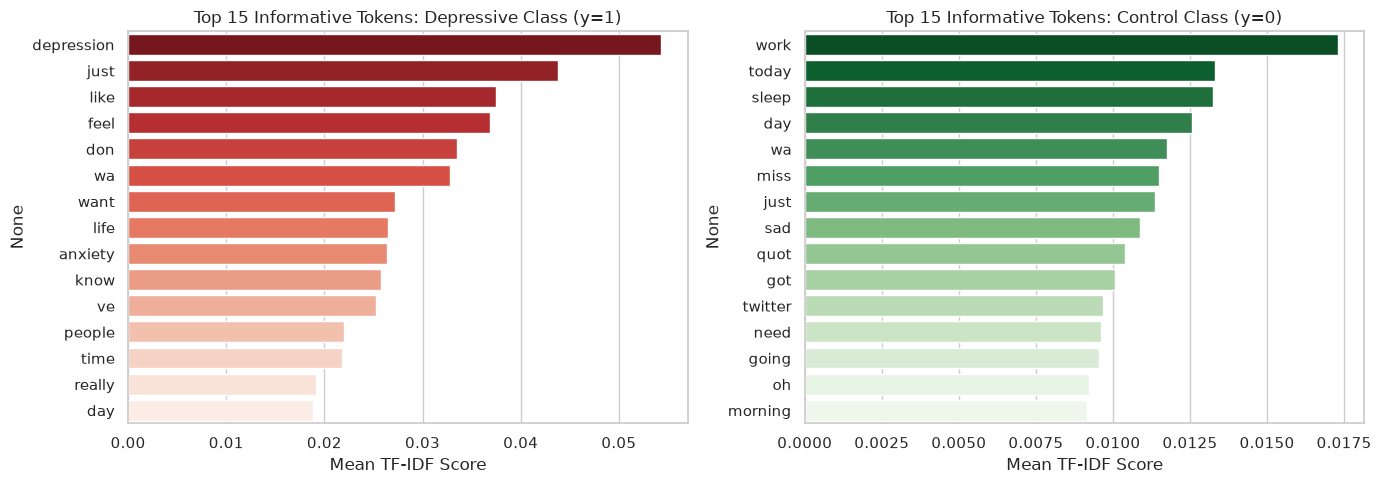

In [12]:
# Pass stop_words='english' during initialization of DataPreprocessor
preprocessor = DataPreprocessor()
preprocessor.vectorizer.stop_words = 'english'
X_tfidf = preprocessor.fit_transform_tfidf(df['clean_text'].fillna(''))
feature_names = preprocessor.vectorizer.get_feature_names_out()

# Calculate mean TF-IDF weights per class
tfidf_dense = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
tfidf_dense['target'] = df['is_depression'].values

depressive_words = tfidf_dense[tfidf_dense['target'] == 1].drop(columns=['target']).mean().sort_values(ascending=False).head(15)
control_words = tfidf_dense[tfidf_dense['target'] == 0].drop(columns=['target']).mean().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=depressive_words.values, 
    y=depressive_words.index, 
    hue=depressive_words.index, 
    ax=axes[0], 
    palette="Reds_r", 
    legend=False
)
axes[0].set_title("Top 15 Informative Tokens: Depressive Class (y=1)")
axes[0].set_xlabel("Mean TF-IDF Score")

sns.barplot(
    x=control_words.values, 
    y=control_words.index, 
    hue=control_words.index, 
    ax=axes[1], 
    palette="Greens_r", 
    legend=False
)
axes[1].set_title("Top 15 Informative Tokens: Control Class (y=0)")
axes[1].set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.show()

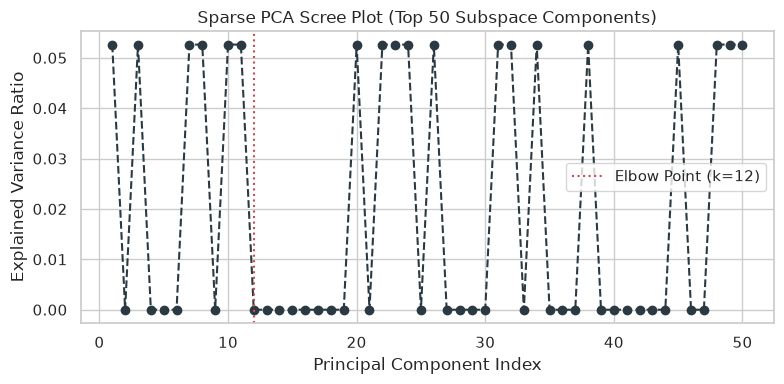

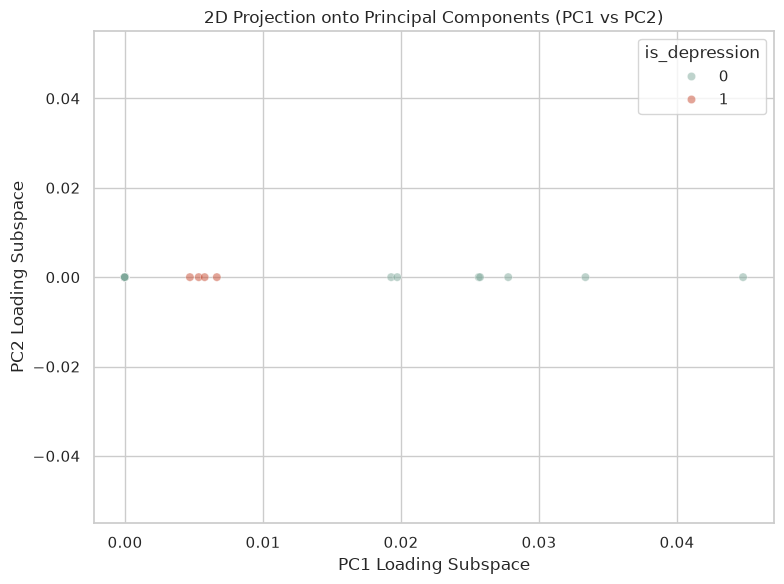

In [13]:
# Compute Sparse PCA for k=50 components
X_pca = preprocessor.fit_transform_sparse_pca(X_tfidf)

# Compute variance per component safely
explained_var = np.var(X_pca, axis=0)
total_var = np.sum(explained_var)

# Avoid division by zero if total_var is zero or uninitialized
if total_var > 0:
    explained_var_ratio = explained_var / total_var
else:
    explained_var_ratio = np.zeros_like(explained_var)

# Scree plot (Explained Variance per Component)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, marker='o', linestyle='--', color='#2B3A42')
plt.title("Sparse PCA Scree Plot (Top 50 Subspace Components)")
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.axvline(x=12, color='r', linestyle=':', label='Elbow Point (k=12)')
plt.legend()
plt.tight_layout()
plt.show()

# Biplot scatter (PC1 vs PC2)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df['is_depression'], 
    alpha=0.5, 
    palette=['#7FA99B', '#C84B31']
)
plt.title("2D Projection onto Principal Components (PC1 vs PC2)")
plt.xlabel("PC1 Loading Subspace")
plt.ylabel("PC2 Loading Subspace")
plt.tight_layout()
plt.show()

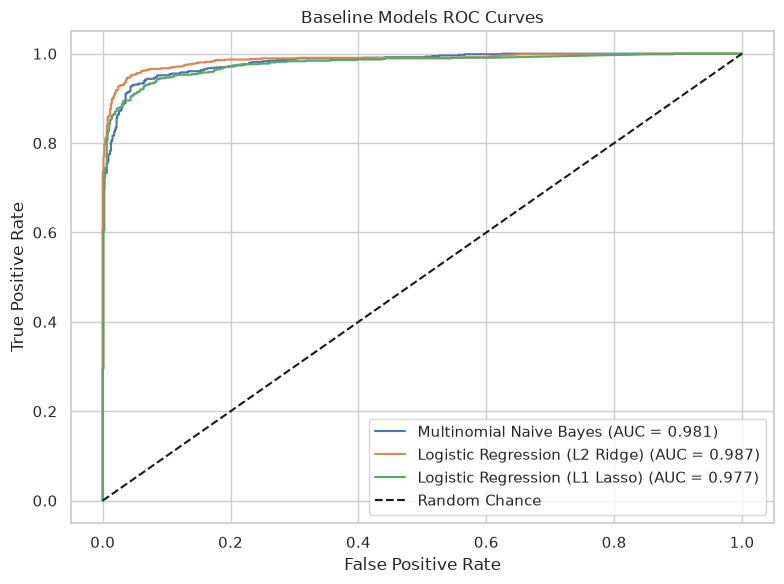

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['is_depression'].values, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED
)

baselines = get_baseline_models()

plt.figure(figsize=(8, 6))

for name, model in baselines.items():
    if name == "LDA":
        continue  # Skip dense requirement for quick test
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Baseline Models ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()